In [1]:
!wget -r -N -c -np https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/

Streaming output truncated to the last 5000 lines.
Length: 4289 (4.2K) [text/plain]
Saving to: ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p019838.psv’

physionet.org/files 100%[===================>]   4.19K  --.-KB/s    in 0s      

2026-06-12 10:34:59 (1.03 GB/s) - ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p019838.psv’ saved [4289/4289]

--2026-06-12 10:34:59--  https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/p019839.psv
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 4059 (4.0K) [text/plain]
Saving to: ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p019839.psv’

physionet.org/files 100%[===================>]   3.96K  --.-KB/s    in 0s      

2026-06-12 10:35:00 (1.28 GB/s) - ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p019839.psv’ saved [4059/4059]

--2026-06-12 10:35:00--  https://physionet.org/files/challenge-2019/1.0.0

In [2]:
!pip install xgboost lightgbm imbalanced-learn -q

In [3]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, brier_score_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


In [4]:
def load_psv_files(folder_path):
    all_files = glob.glob(folder_path + "/*.psv")
    dfs = []
    for f in all_files:
        df = pd.read_csv(f, sep='|')
        patient_id = os.path.basename(f).replace('.psv', '')
        df['patient_id'] = patient_id
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

print("Loading training_setA...")
setA = load_psv_files('/content/physionet.org/files/challenge-2019/1.0.0/training/training_setA')
print(f"SetA shape: {setA.shape}")
print("Done!")

Loading training_setA...
SetA shape: (790215, 42)
Done!


In [6]:
target = 'SepsisLabel'

feature_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
                'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
                'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
                'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium',
                'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI',
                'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets',
                'Age', 'Gender', 'ICULOS']


setA = setA.sort_values(['patient_id', 'ICULOS'])

setA[feature_cols] = setA.groupby('patient_id')[feature_cols].transform(
    lambda x: x.ffill()
)

setA[feature_cols] = setA[feature_cols].fillna(setA[feature_cols].median())

print("Missing values after preprocessing:")
print(setA[feature_cols].isnull().sum().sum())
print("Preprocessing done!")

Missing values after preprocessing:
790215
Preprocessing done!


In [7]:
for col in feature_cols:
    median_val = setA[col].median()
    setA[col] = setA[col].fillna(median_val)

print("Missing values after fix:")
print(setA[feature_cols].isnull().sum().sum())
print("Done!")

Missing values after fix:
790215
Done!


In [8]:
print("Missing values per column:")
print(setA[feature_cols].isnull().sum())
print("\nTotal rows:", len(setA))

Missing values per column:
HR                       0
O2Sat                    0
Temp                     0
SBP                      0
MAP                      0
DBP                      0
Resp                     0
EtCO2               790215
BaseExcess               0
HCO3                     0
FiO2                     0
pH                       0
PaCO2                    0
SaO2                     0
AST                      0
BUN                      0
Alkalinephos             0
Calcium                  0
Chloride                 0
Creatinine               0
Bilirubin_direct         0
Glucose                  0
Lactate                  0
Magnesium                0
Phosphate                0
Potassium                0
Bilirubin_total          0
TroponinI                0
Hct                      0
Hgb                      0
PTT                      0
WBC                      0
Fibrinogen               0
Platelets                0
Age                      0
Gender                   0
I

In [9]:
feature_cols.remove('EtCO2')
print("EtCO2 removed!")
print(f"Features remaining: {len(feature_cols)}")
print("Missing values now:", setA[feature_cols].isnull().sum().sum())

EtCO2 removed!
Features remaining: 36
Missing values now: 0


In [10]:
def create_early_labels(group, hours_before=6):
    group = group.copy()
    group['EarlyLabel'] = 0
    sepsis_time = group[group[target] == 1]['ICULOS'].min()
    if not pd.isna(sepsis_time):
        early_time = sepsis_time - hours_before
        group.loc[group['ICULOS'] >= early_time, 'EarlyLabel'] = 1
    return group

print("Creating 6-hour early labels...")
setA = setA.groupby('patient_id', group_keys=False).apply(create_early_labels)
print(f"Positive labels: {setA['EarlyLabel'].sum()}")
print(f"Negative labels: {(setA['EarlyLabel']==0).sum()}")
print("Done!")

Creating 6-hour early labels...
Positive labels: 26030
Negative labels: 764185
Done!


In [11]:
patients = setA['patient_id'].unique()
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

train_df = setA[setA['patient_id'].isin(train_patients)]
test_df = setA[setA['patient_id'].isin(test_patients)]

X_train = train_df[feature_cols]
y_train = train_df['EarlyLabel']
X_test = test_df[feature_cols]
y_test = test_df['EarlyLabel']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print("Done!")

Train size: (631113, 36)
Test size: (159102, 36)
Done!


In [12]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

print("Training started... (5-10 min lagenge)")
model.fit(X_train_scaled, y_train,
          eval_set=[(X_test_scaled, y_test)],
          verbose=50)

print("Model training complete!")

Training started... (5-10 min lagenge)
[0]	validation_0-logloss:0.68212
[50]	validation_0-logloss:0.51128
[100]	validation_0-logloss:0.46998
[150]	validation_0-logloss:0.44786
[200]	validation_0-logloss:0.42657
[250]	validation_0-logloss:0.41102
[299]	validation_0-logloss:0.39671
Model training complete!


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93    153944
           1       0.12      0.49      0.19      5158

    accuracy                           0.87    159102
   macro avg       0.55      0.68      0.56    159102
weighted avg       0.95      0.87      0.90    159102



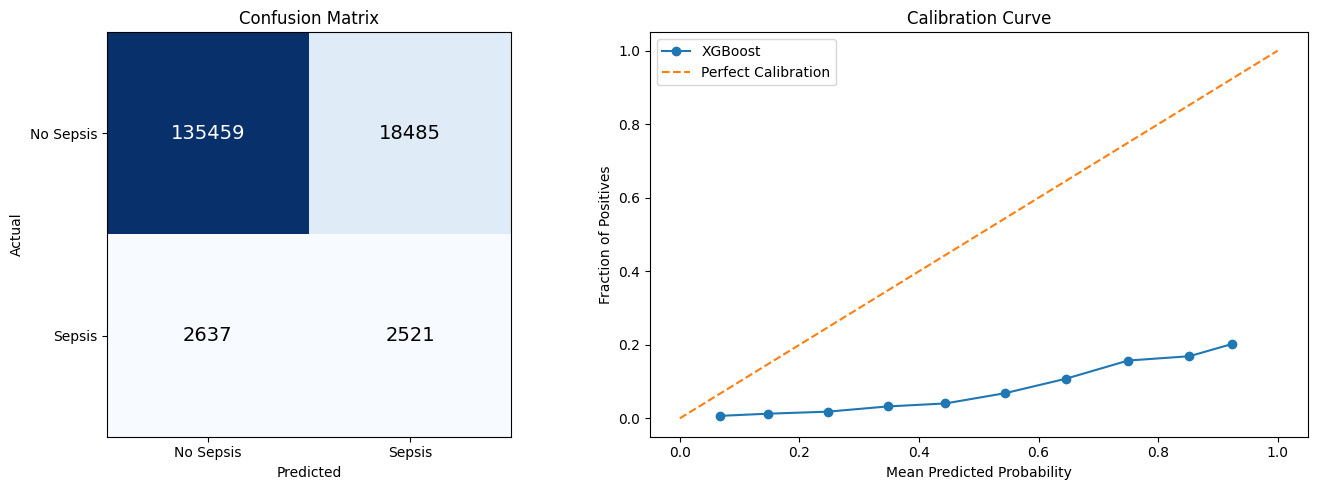

Brier Score: 0.1192


In [13]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
labels = ['No Sepsis', 'Sepsis']
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(labels)
axes[0].set_yticklabels(labels)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')

fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
axes[1].plot(mean_pred, fraction_pos, marker='o', label='XGBoost')
axes[1].plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')
axes[1].set_title('Calibration Curve')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend()

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

print(f"Brier Score: {brier_score_loss(y_test, y_prob):.4f}")

In [14]:
import pickle

with open('sepsis_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved!")

Model saved!
